In [176]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [177]:
import pandas as pd; pd.set_option("display.max_columns", None)
import sys;sys.path.append("..")
from config import Paths
from dataframes import *
from eals_data.utils import venn_diagram
from eals_radcliff.utils import dataframes as radcliff_dataframes
from eals_radcliff.utils import dataframes_paper as radcliff_dataframes_paper

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt
from eals_radcliff.models.LMM import model as lmm_model

# Zephyr X

### RAPA

In [179]:
### No filtering here
at_least_efforts_fvc_usable=0
keep_usable_sessions_only=False
at_least_months_in_study=0
at_least_n_sessions=0
multiply_by_100=True


df_zephyrx_new = load_zephyrx_data(
    at_least_efforts_fvc_usable=at_least_efforts_fvc_usable,
    keep_usable_sessions_only=keep_usable_sessions_only,
    at_least_months_in_study=at_least_months_in_study,
    at_least_n_sessions=at_least_n_sessions,
    multiply_by_100=multiply_by_100,
)
print(f'N pALS: {df_zephyrx_new.user_id.nunique()}, N sessions: {df_zephyrx_new.session_id.nunique()}')

# Keep only one spirometry per session (best one)
df_best_fvc_per_session = df_zephyrx_new.query('pftType=="fvc"').sort_values(['user_id', 'fvcPercPred_2019'], ascending=False).groupby('session_id').first().reset_index()
df_best_svc_per_session = df_zephyrx_new.query('pftType=="svc"').sort_values(['user_id', 'vcPercPred'], ascending=False).groupby('session_id').first().reset_index()
df_zephyrx_new = pd.concat([df_best_fvc_per_session, df_best_svc_per_session])
df_zephyrx_svc = df_zephyrx_new.query('pftType=="svc"').copy()
print(f'Before keeping VC>0 -> N pALS: {df_zephyrx_svc.user_id.nunique()}, N sessions: {df_zephyrx_svc.session_id.nunique()}')
df_zephyrx_svc = df_zephyrx_svc.query('vc > 0').copy()
print(f'After keeping VC>0 -> N pALS: {df_zephyrx_svc.user_id.nunique()}, N sessions: {df_zephyrx_svc.session_id.nunique()}')

--- SCALING PERC PRED VARS TO PERCENTAGE: fvcPercPred_2019, vcPercPred
1 - ORIGINAL DIMENSIONS:                           subjects:     13, sessions:    126, spiro:    295, cols: 108
--- KEEP SESSIONS THAT MAY NOT MET USABILITY CRITERIA (eals_usability column)
--- WARNING computing 'total_timespan' for each user after usability criteria: False
--- TOTAL TIMESPAN: min 0, max 671, mean 341.71
--- NOT FILTERING SUBJECTS BY MINIMUM MONTHS IN STUDY
--- NOT FILTERING SUBJECTS BY MINIMUM NUMBER OF SESSIONS
N pALS: 13, N sessions: 126
Before keeping VC>0 -> N pALS: 12, N sessions: 115
After keeping VC>0 -> N pALS: 11, N sessions: 104


In [180]:
# Compute months since the first session per user (vectorized)
first_date = df_zephyrx_svc.groupby('user_id')['date'].transform('min')
months = (df_zephyrx_svc['date'] - first_date) / np.timedelta64(30, 'D')  # ~months as float
df_zephyrx_svc.loc[:, 'months_since_first_session'] = months
df_zephyrx_svc.loc[:, 'years_since_first_session'] = df_zephyrx_svc['months_since_first_session'] / 12.0

vcPercPred_zscore ~ years_since_first_session
1 + years_since_first_session


                     Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      vcPercPred_zscore
No. Observations:        104          Method:                  REML             
No. Groups:              11           Scale:                   0.2717           
Min. group size:         1            Log-Likelihood:          -99.3821         
Max. group size:         26           Converged:               Yes              
Mean group size:         9.5                                                    
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.477    0.267 -1.788 0.074 -0.999  0.046
years_since_first_session             -0.481    0.873 -0.551 0.581 -2.192  1.230
Group Var                              0.684    0.

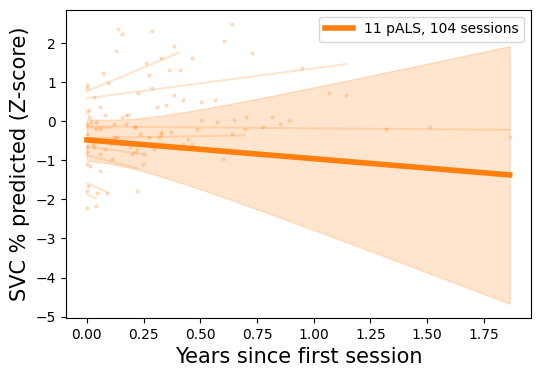

Population	Intercept (SE)	Slope (SE) (1/Years)
11 pALS, 104 sessions	-0.477 (0.267)	-0.481 (0.873)


In [181]:
# dependant_variable = 'fvcPercPred_2019'
dependant_variable = 'vcPercPred'

if not dependant_variable.startswith('fvc'):
    pftType = 'svc'
    df_plot = df_zephyrx_svc.copy()
else:
    raise

# Compute z score
df_plot[f'{dependant_variable}_zscore'] = (df_plot[dependant_variable] - df_plot[dependant_variable].mean()) / df_plot[dependant_variable].std()

dependant_variable_title = f"{pftType.upper()} % predicted (Z-score)"
result_dict = lmm_model.run_lmm_analysis(
    df_plot,
    # dependant_variable= dependant_variable,
    dependant_variable= f'{dependant_variable}_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= None,
    label_false= None,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

### Radcliff

In [182]:
from eals_radcliff.utils import dataframes_paper

### No filtering here
at_least_efforts_fvc_usable=0
keep_usable_sessions_only=False
at_least_months_in_study=0
at_least_n_sessions=0
multiply_by_100=True

df_zephyrx_radcliff = dataframes_paper.load_zephyrx_data_paper(
    at_least_efforts_fvc_usable=at_least_efforts_fvc_usable,
    keep_usable_sessions_only=keep_usable_sessions_only,
    at_least_months_in_study=at_least_months_in_study,
    at_least_n_sessions=at_least_n_sessions,
    multiply_by_100=multiply_by_100,
)

df_zephyrx_radcliff.rename(columns={'subject_id': 'user_id', 'date_only': 'date'}, inplace=True)

print(f'N pALS: {df_zephyrx_radcliff.user_id.nunique()}, N sessions: {df_zephyrx_radcliff.session_id.nunique()}')

# Keep only one spirometry per session (best one)
df_best_fvc_per_session = df_zephyrx_radcliff.query('pftType=="fvc"').sort_values(['user_id', 'fvcPercPred_2019'], ascending=False).groupby('session_id').first().reset_index()
df_best_svc_per_session = df_zephyrx_radcliff.query('pftType=="svc"').sort_values(['user_id', 'vcPercPred'], ascending=False).groupby('session_id').first().reset_index()
df_zephyrx_radcliff = pd.concat([df_best_fvc_per_session, df_best_svc_per_session])
df_zephyrx_svc_radcliff = df_zephyrx_radcliff.query('pftType=="svc"').copy()
print(f'Before keeping VC>0 -> N pALS: {df_zephyrx_svc_radcliff.user_id.nunique()}, N sessions: {df_zephyrx_svc_radcliff.session_id.nunique()}')
df_zephyrx_svc_radcliff = df_zephyrx_svc_radcliff.query('vc > 0').copy()
print(f'After keeping VC>0 -> N pALS: {df_zephyrx_svc_radcliff.user_id.nunique()}, N sessions: {df_zephyrx_svc_radcliff.session_id.nunique()}')

--- SCALING PERC PRED VARS TO PERCENTAGE: fvcPercPred_2019, vcPercPred
1 - ORIGINAL DIMENSIONS:                           subjects:     74, sessions:   1552, spiro:   3874, cols: 109
2 - EXCLUDING ANY OF 46 TEST USERS:                subjects:     74, sessions:   1552, spiro:   3874, cols: 109
3 - EXCLUDING ONLY ZX SESSIONS:                    subjects:     73, sessions:   1477, spiro:   3655, cols: 109
4 - AFTER PULMONOLOGIST (2023-03-01):              subjects:     70, sessions:   1397, spiro:   3486, cols: 109
--- KEEP SESSIONS THAT MAY NOT MET USABILITY CRITERIA (eals_usability column)
--- WARNING computing 'total_timespan' for each patient after usability criteria: False
--- TOTAL TIMESPAN: min 0, max 728, mean 405.99
--- NOT FILTERING SUBJECTS BY MINIMUM MONTHS IN STUDY
--- NOT FILTERING SUBJECTS BY MINIMUM NUMBER OF SESSIONS
--- ADDING REGRESSION COLUMNS FOR MIN 3 SESSIONS PER SUBJ FOR EACH pftType PercPred
--- REGRESSION COLUMNS COMPUTED                    subjects:     70, ses

##### Criteria

In [183]:
from scipy import stats

def get_ks_test(list1, list2):
    statistic, p_value = stats.ks_2samp(list1, list2)

    # if p_value >= 0.05:
    #     print("→ Fail to reject H₀: no significant difference detected.")
    #     print(f"Mean list1: {np.mean(list1):.2f}")
    #     print(f"Mean list2: {np.mean(list2):.2f}")
        
    return statistic, p_value

In [184]:
##### CRITERIA
criteria = 'd'

if criteria == 'a':
    print('Keep only those similar in vcPercPred')
    pals_to_keep = df_zephyrx_svc_radcliff.sort_values(['user_id','date']).groupby('user_id').vcPercPred.first()<=60
    pals_to_keep = pals_to_keep[pals_to_keep].index
    print(len(pals_to_keep))

elif criteria == 'b':
    rapa_svc_enroll = df_zephyrx_svc.sort_values(['user_id','date']).groupby('user_id').vcPercPred.first()
    radcliff_svc_enroll = df_zephyrx_svc_radcliff.sort_values(['user_id','date']).groupby('user_id').vcPercPred.first()

    p_value = 0
    i=-1
    while p_value < 0.05:
        i+=1
        this_rad_sample = radcliff_svc_enroll.sample(11, random_state=i)
        statistic, p_value = get_ks_test(rapa_svc_enroll, this_rad_sample)

    print(f"Achieved at iteration {i}")
    pals_to_keep = this_rad_sample.index
    print(len(pals_to_keep))

elif criteria == 'c':
    # By ALSFRS-R at e
    df_als = load_alsfrsr_data()[['user_id', 'ALS_total', 'date']]
    rapa_als_enroll = df_als.sort_values(['user_id','date']).groupby('user_id').ALS_total.first()

    df_als_rad = radcliff_dataframes.load_alsfrsr_data()[['user_id', 'ALS_total', 'date']]
    rad_als_enroll = df_als_rad.sort_values(['user_id','date']).groupby('user_id').ALS_total.first()

    p_value = 0
    i=-1
    while p_value < 0.05:
        i+=1
        this_rad_sample = rad_als_enroll.sample(6, random_state=i)
        statistic, p_value = get_ks_test(rapa_als_enroll, this_rad_sample)
    
    print(f"Achieved at iteration {i}")
    pals_to_keep = this_rad_sample.index
    print(len(pals_to_keep))

elif criteria == 'd':
    import random

    # SVC
    rapa_svc_enroll = df_zephyrx_svc.sort_values(['user_id','date']).groupby('user_id').vcPercPred.first()
    radcliff_svc_enroll = df_zephyrx_svc_radcliff.sort_values(['user_id','date']).groupby('user_id').vcPercPred.first()

    # ALSFRS-R
    df_als = load_alsfrsr_data()[['user_id', 'ALS_total', 'date']]
    rapa_als_enroll = df_als.sort_values(['user_id','date']).groupby('user_id').ALS_total.first()
    df_als_rad = radcliff_dataframes.load_alsfrsr_data()[['user_id', 'ALS_total', 'date']]
    rad_als_enroll = df_als_rad.sort_values(['user_id','date']).groupby('user_id').ALS_total.first()

    # In both
    in_both = list(set(radcliff_svc_enroll.index.tolist()) & set(rad_als_enroll.index.tolist()))

    p_value_1 = 0
    p_value_2 = 0
    i=-1
    while p_value_1 < 0.05 or p_value_2 < 0.05:
        i+=1

        rng = random.Random(i)
        sample = rng.sample(in_both, k=6)

        this_rad_svc_sample = radcliff_svc_enroll.loc[sample]
        statistic, p_value_1 = get_ks_test(this_rad_svc_sample, rapa_svc_enroll)

        this_rad_als_sample = rad_als_enroll.loc[sample]
        statistic, p_value_2 = get_ks_test(this_rad_als_sample, rapa_als_enroll)
    
    print(f"Achieved at iteration {i}")
    pals_to_keep = sample
    print(len(pals_to_keep))
    print(p_value_1, p_value_2)

### Filter
df_zephyrx_svc_radcliff_criteria = df_zephyrx_svc_radcliff.query('user_id in @pals_to_keep')

# Compute months since the first session per user (vectorized)
first_date = df_zephyrx_svc_radcliff_criteria.groupby('user_id')['date'].transform('min')
months = (df_zephyrx_svc_radcliff_criteria['date'] - first_date) / np.timedelta64(30, 'D')  # ~months as float
df_zephyrx_svc_radcliff_criteria.loc[:, 'months_since_first_session'] = months
df_zephyrx_svc_radcliff_criteria.loc[:, 'years_since_first_session'] = df_zephyrx_svc_radcliff_criteria['months_since_first_session'] / 12.0

Achieved at iteration 3616
6
0.18495475113122173 0.06738189346885


In [185]:
print(f"Mean list1: {np.mean(this_rad_svc_sample):.2f}")
print(f"Mean list2: {np.mean(rapa_svc_enroll):.2f}")
p_value_1

Mean list1: 66.00
Mean list2: 38.55


0.18495475113122173

##### LMM

vcPercPred_zscore ~ years_since_first_session
1 + years_since_first_session


                     Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      vcPercPred_zscore
No. Observations:        119          Method:                  REML             
No. Groups:              6            Scale:                   0.0388           
Min. group size:         1            Log-Likelihood:          5.0829           
Max. group size:         40           Converged:               Yes              
Mean group size:         19.8                                                   
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.309    0.435 -0.711 0.477 -1.163  0.544
years_since_first_session             -0.524    0.139 -3.770 0.000 -0.796 -0.251
Group Var                              1.122    3.

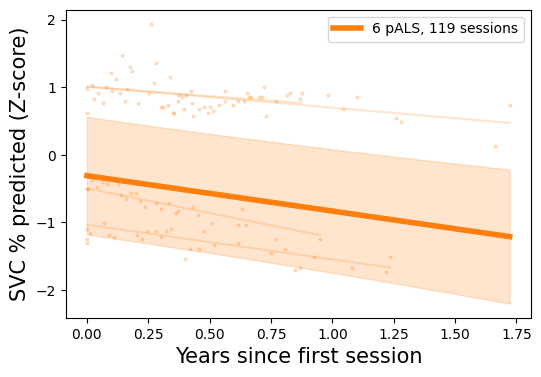

Population	Intercept (SE)	Slope (SE) (1/Years)
6 pALS, 119 sessions	-0.309 (0.435)	-0.524 (0.139)


In [186]:
# dependant_variable = 'fvcPercPred_2019'
dependant_variable = 'vcPercPred'

if not dependant_variable.startswith('fvc'):
    pftType = 'svc'
    df_plot = df_zephyrx_svc_radcliff_criteria.copy()
else:
    raise

# Compute z score
df_plot[f'{dependant_variable}_zscore'] = (df_plot[dependant_variable] - df_plot[dependant_variable].mean()) / df_plot[dependant_variable].std()

dependant_variable_title = f"{pftType.upper()} % predicted (Z-score)"
result_dict = lmm_model.run_lmm_analysis(
    df_plot,
    # dependant_variable= dependant_variable,
    dependant_variable= f'{dependant_variable}_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= None,
    label_false= None,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

#### Combined

In [187]:
VISIT_TYPE = 'C1D1' # Screening C1D1

In [188]:
### BUILD CUTOFF DATE
# VISIT_TYPE = 'Screening' # Screening C1D1

GT_PATH = '../data/RAPA EALS Participant Data Set v1 04-13-2026.xlsx'

df_gt = pd.read_excel(GT_PATH)
df_gt = df_gt.rename(columns={'EALS ID': 'user_id', 'RAPA ID': 'rapa_id'})
rapa_to_eals = {row['rapa_id']:row['user_id'] for i, row in df_gt[['user_id','rapa_id']].drop_duplicates().iterrows()}

TARGET_COLS = ['Date', 'Visit Type', 'Source']

def parse_sheet(xl, sheet):
    raw = xl.parse(sheet, header=None)
    mask = raw.apply(lambda row: row.astype(str).str.strip().tolist(), axis=1).apply(
        lambda vals: all(c in vals for c in TARGET_COLS)
    )
    header_row = mask.idxmax()
    raw.columns = raw.iloc[header_row]
    return raw.iloc[header_row + 1:][TARGET_COLS].reset_index(drop=True)

xl = pd.ExcelFile(GT_PATH)
sheet_names = xl.sheet_names
sheets = {sheet_names[0]: xl.parse(sheet_names[0])}
sheets.update({sheet: parse_sheet(xl, sheet) for sheet in sheet_names[1:]})
sheets = {rapa_to_eals.get(k.split(',')[0].strip(), k):v for k,v in sheets.items()}

names_and_dosis_cutoff = {}
name_list = list(sheets.keys())[1:]
for name in name_list:
    df_s = sheets[name].copy()
    df_s.columns = [c.lower().replace(' ','_') for c in df_s.columns]
    df_s["date"] = pd.to_datetime(df_s["date"], dayfirst=False, infer_datetime_format=True, errors="coerce")
    name_date = df_s.query('visit_type==@VISIT_TYPE').date.iloc[0]
    names_and_dosis_cutoff.update({name:name_date})
    
# Map each user_id to its cutoff date from the dictionary
df_zephyrx_svc["cutoff_date"] = df_zephyrx_svc["user_id"].map(names_and_dosis_cutoff)

# Keep rows where the row's date is after the cutoff
df_filtered = df_zephyrx_svc[df_zephyrx_svc["date"] >= df_zephyrx_svc["cutoff_date"]].drop(columns="cutoff_date")
df_not_filtered = df_zephyrx_svc.query('user_id not in @name_list')
df_zephyrx_svc_final = pd.concat([df_filtered,df_not_filtered])

In [189]:
dependant_variable = 'vcPercPred'

df1 = df_zephyrx_svc_radcliff_criteria[['user_id', 'years_since_first_session', 'date', 'session_id', dependant_variable]].copy()
df1['is_rapa'] = False
df2 = df_zephyrx_svc_final[['user_id', 'years_since_first_session', 'date', 'session_id', dependant_variable]].copy()
df2['is_rapa'] = True
df_fix = pd.concat([
    df1, 
    df2
    ], ignore_index=True)

vcPercPred ~ years_since_first_session*is_rapa
1 + years_since_first_session
                      Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         vcPercPred
No. Observations:           211             Method:                     REML      
No. Groups:                 16              Scale:                      58.9367   
Min. group size:            1               Log-Likelihood:             -755.4375 
Max. group size:            40              Converged:                  Yes       
Mean group size:            13.2                                                  
----------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                              70.549   10.037  7.029 0.000  50.877 90.221
years_since_first_session        

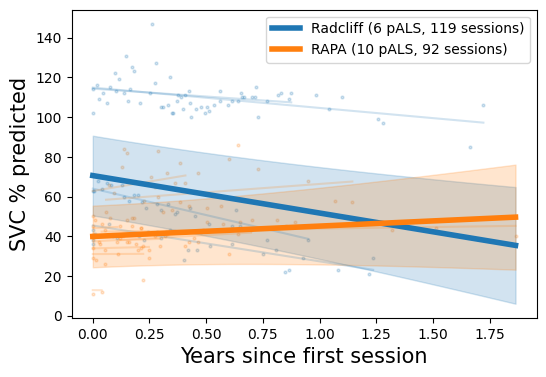

Population	Intercept (SE)	Slope (SE) (1/Years)
Radcliff (6 pALS, 119 sessions)	70.549 (10.037)	-18.858 (5.749)
RAPA (10 pALS, 92 sessions)	39.892 (7.761)	5.221 (5.741)
Interaction	-30.657 (12.687)	24.079 (8.075)


In [190]:
label_false = 'Radcliff'
label_true = 'RAPA' 
grouping_variable = 'is_rapa'

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

df_plot = df_fix.copy()

# Compute z score
df_plot[f'{dependant_variable}_zscore'] = (df_plot[dependant_variable] - df_plot[dependant_variable].mean()) / df_plot[dependant_variable].std()

dependant_variable_title = f"SVC % predicted"
result_dict = lmm_model.run_lmm_analysis(
    df_plot,
    dependant_variable= dependant_variable,
    # dependant_variable = f'{dependant_variable}_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    label_true= label_true,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

# Target ALS